In [1]:
# =============================================================================
# SEGMENTAÇÃO DE ROTAS AÉREAS USANDO K-MEANS
# =============================================================================
# Objetivo: Identificar grupos de rotas com características similares
# baseando-se em atraso médio, distância e frequência de voos.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
# =============================================================================
# 1. CARREGAMENTO DOS DADOS
# =============================================================================
# Carrega o dataset de voos - ajuste o caminho conforme necessário
print("Carregando dados...")
flights = pd.read_csv('data/flights.csv', low_memory=False)

print(f"Dataset carregado: {flights.shape[0]:,} voos, {flights.shape[1]} colunas")
print(f"\nColunas disponíveis: {flights.columns.tolist()}")

Carregando dados...
Dataset carregado: 5,819,079 voos, 31 colunas

Colunas disponíveis: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']


In [3]:
# =============================================================================
# 2. ENGENHARIA DE FEATURES
# =============================================================================
# Por que agrupar por rota?
# - Queremos entender o comportamento de ROTAS, não de voos individuais
# - Cada rota (origem -> destino) terá métricas agregadas que caracterizam seu perfil

print("\n" + "="*60)
print("ENGENHARIA DE FEATURES - Agregação por Rota")
print("="*60)

# Agrupa os dados por rota (combinação origem-destino)
# Calcula métricas que caracterizam cada rota:
# - avg_delay: indica a pontualidade típica da rota
# - avg_distance: caracteriza rotas curtas vs longas
# - flight_count: indica a popularidade/frequência da rota
route_features = flights.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).agg({
    'DEPARTURE_DELAY': 'mean',  # Atraso médio na partida (minutos)
    'ARRIVAL_DELAY': 'mean',    # Atraso médio na chegada (minutos)
    'DISTANCE': 'mean',         # Distância média (milhas)
    'FLIGHT_NUMBER': 'count'    # Contagem de voos (frequência)
}).reset_index()

# Renomeia colunas para clareza
route_features.columns = [
    'origin', 'destination',
    'avg_departure_delay', 'avg_arrival_delay',
    'avg_distance', 'flight_count'
]

# Cria identificador único para cada rota
route_features['route'] = route_features['origin'] + ' → ' + route_features['destination']

print(f"\nTotal de rotas únicas identificadas: {len(route_features):,}")
print(f"\nPrimeiras rotas:")
print(route_features.head(10))


ENGENHARIA DE FEATURES - Agregação por Rota

Total de rotas únicas identificadas: 8,609

Primeiras rotas:
  origin destination  avg_departure_delay  avg_arrival_delay  avg_distance  \
0  10135       10397             5.931818           2.159091         692.0   
1  10135       11433            14.626667          11.533333         425.0   
2  10135       13930             8.171053           6.763158         655.0   
3  10136       11298             4.061856          -6.005208         158.0   
4  10140       10397            -0.373626          -5.054945        1269.0   
5  10140       10821             4.483871          -6.370968        1670.0   
6  10140       11259             7.206897           7.209790         580.0   
7  10140       11292             8.391304           2.993789         349.0   
8  10140       11298             9.890110           5.350000         569.0   
9  10140       12191             3.511364          -1.160920         759.0   

   flight_count          route  
0

In [4]:
# =============================================================================
# 3. PRÉ-PROCESSAMENTO
# =============================================================================
# Por que tratar nulos?
# - K-Means não aceita valores NaN
# - Rotas com dados faltantes podem distorcer os clusters

print("\n" + "="*60)
print("PRÉ-PROCESSAMENTO")
print("="*60)

# Verifica valores nulos antes do tratamento
print("\nValores nulos por coluna:")
print(route_features.isnull().sum())

# Remove rotas com valores nulos (alternativa: imputação)
# Optamos por remoção pois queremos clusters baseados em dados reais
route_features_clean = route_features.dropna()
print(f"\nRotas após remoção de nulos: {len(route_features_clean):,}")

# Seleciona features numéricas para clustering
# Usamos atraso de partida como métrica principal de pontualidade
features_for_clustering = ['avg_departure_delay', 'avg_distance', 'flight_count']
X = route_features_clean[features_for_clustering].copy()

print(f"\nEstatísticas das features antes da normalização:")
print(X.describe())

# Por que normalizar com StandardScaler?
# - K-Means usa distância euclidiana
# - Features com escalas diferentes (ex: distância em milhares vs atraso em minutos)
#   dominariam o cálculo de distância
# - StandardScaler: transforma para média=0 e desvio=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nDados normalizados (média≈0, std≈1):")
print(f"Médias: {X_scaled.mean(axis=0).round(4)}")
print(f"Desvios: {X_scaled.std(axis=0).round(4)}")


PRÉ-PROCESSAMENTO

Valores nulos por coluna:
origin                  0
destination             0
avg_departure_delay     3
avg_arrival_delay      39
avg_distance            0
flight_count            0
route                   0
dtype: int64

Rotas após remoção de nulos: 8,570

Estatísticas das features antes da normalização:
       avg_departure_delay  avg_distance  flight_count
count          8570.000000   8570.000000   8570.000000
mean              7.831871    904.699749    679.000467
std              10.041051    672.795277   1135.841389
min             -26.000000     31.000000      1.000000
25%               3.123258    419.000000     62.000000
50%               7.108261    740.000000    225.000000
75%              11.065832   1162.000000    777.000000
max             341.000000   4983.000000  13744.000000

Dados normalizados (média≈0, std≈1):
Médias: [0. 0. 0.]
Desvios: [1. 1. 1.]



MÉTODO DO COTOVELO
k= 1 | Inércia: 25,710.00
k= 2 | Inércia: 19,892.14
k= 3 | Inércia: 14,558.58
k= 4 | Inércia: 11,068.99
k= 5 | Inércia: 9,258.14
k= 6 | Inércia: 7,846.59
k= 7 | Inércia: 6,917.18
k= 8 | Inércia: 6,206.82
k= 9 | Inércia: 5,685.28
k=10 | Inércia: 5,247.55


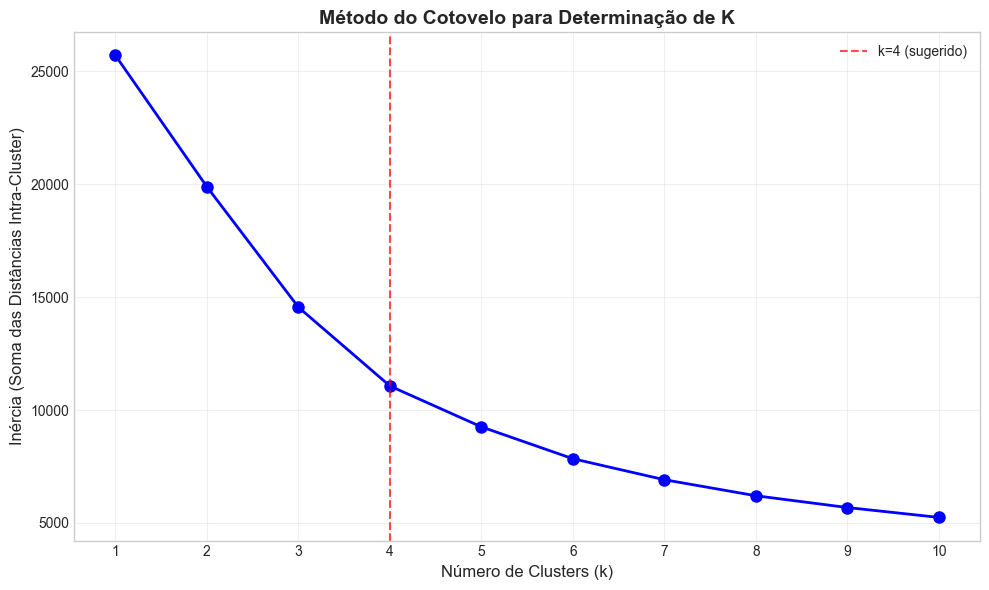


→ Gráfico salvo como 'elbow_method.png'
→ Análise: O 'cotovelo' aparece entre k=3 e k=5
→ Escolhemos k=4 como um bom equilíbrio entre simplicidade e separação


In [5]:
# =============================================================================
# 4. MÉTODO DO COTOVELO (ELBOW METHOD)
# =============================================================================
# Por que usar o método do cotovelo?
# - Ajuda a identificar o número ideal de clusters
# - Procuramos o ponto onde adicionar mais clusters
#   não reduz significativamente a inércia (soma das distâncias intra-cluster)

print("\n" + "="*60)
print("MÉTODO DO COTOVELO")
print("="*60)

# Testa diferentes valores de k
k_range = range(1, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k:2d} | Inércia: {kmeans.inertia_:,.2f}")

# Gráfico do cotovelo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inércia (Soma das Distâncias Intra-Cluster)', fontsize=12)
plt.title('Método do Cotovelo para Determinação de K', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Destaca o ponto sugerido (k=4)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (sugerido)')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n→ Gráfico salvo como 'elbow_method.png'")
print("→ Análise: O 'cotovelo' aparece entre k=3 e k=5")
print("→ Escolhemos k=4 como um bom equilíbrio entre simplicidade e separação")


VALIDAÇÃO COM SILHOUETTE SCORE
k= 2 | Silhouette Score: 0.3988
k= 3 | Silhouette Score: 0.4340
k= 4 | Silhouette Score: 0.4383
k= 5 | Silhouette Score: 0.3211
k= 6 | Silhouette Score: 0.3491
k= 7 | Silhouette Score: 0.3189
k= 8 | Silhouette Score: 0.2944
k= 9 | Silhouette Score: 0.2903
k=10 | Silhouette Score: 0.2920

→ Melhor K pelo Silhouette Score: 4


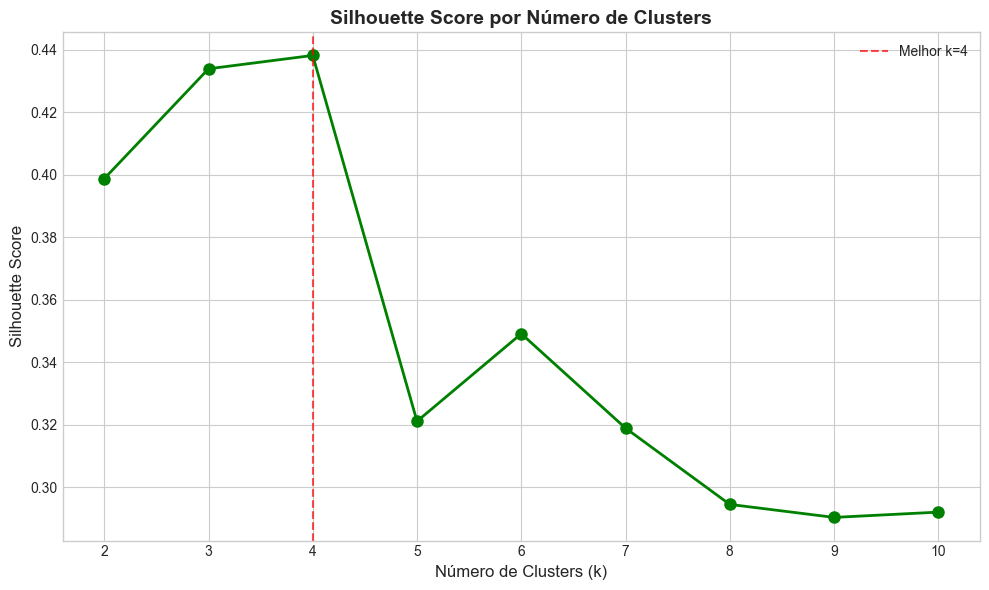

In [6]:
# =============================================================================
# 4.1 VALIDAÇÃO COM SILHOUETTE SCORE
# =============================================================================
# Por que usar Silhouette Score?
# - Mede a qualidade dos clusters objetivamente
# - Considera coesão (quão próximos estão os pontos do mesmo cluster)
# - Considera separação (quão distantes estão de outros clusters)
# - Score varia de -1 a 1: quanto maior, melhor

from sklearn.metrics import silhouette_score

print("\n" + "="*60)
print("VALIDAÇÃO COM SILHOUETTE SCORE")
print("="*60)

silhouette_scores = []

for k in range(2, 11):  # Silhouette requer k >= 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k:2d} | Silhouette Score: {score:.4f}")

# Determina o melhor k automaticamente
best_k = np.argmax(silhouette_scores) + 2  # +2 porque começamos em k=2
print(f"\n→ Melhor K pelo Silhouette Score: {best_k}")

# Visualização
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score por Número de Clusters', fontsize=14, fontweight='bold')
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Melhor k={best_k}')
plt.xticks(range(2, 11))
plt.legend()
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# =============================================================================
# 5. MODELAGEM FINAL - K-MEANS COM K=4
# =============================================================================
# Por que k=4?
# - Baseado no método do cotovelo
# - Permite interpretação clara: rotas podem ser categorizadas em 4 perfis distintos

print("\n" + "="*60)
print("MODELAGEM FINAL - K-MEANS (k=4)")
print("="*60)

# Define número de clusters
N_CLUSTERS = best_k#4

# Treina o modelo final
kmeans_final = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10,      # Número de inicializações (evita mínimos locais)
    max_iter=300    # Máximo de iterações por execução
)

# Aplica clustering e adiciona labels ao dataframe
route_features_clean['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\nDistribuição dos clusters:")
print(route_features_clean['cluster'].value_counts().sort_index())

# Análise do perfil de cada cluster
print("\n" + "-"*60)
print("PERFIL MÉDIO DE CADA CLUSTER:")
print("-"*60)

cluster_profiles = route_features_clean.groupby('cluster')[features_for_clustering].mean()
cluster_profiles['count'] = route_features_clean.groupby('cluster').size()
print(cluster_profiles.round(2))

# Interpretação dos clusters
print("\n" + "-"*60)
print("INTERPRETAÇÃO DOS CLUSTERS:")
print("-"*60)

for cluster_id in range(N_CLUSTERS):
    cluster_data = route_features_clean[route_features_clean['cluster'] == cluster_id]
    avg_delay = cluster_data['avg_departure_delay'].mean()
    avg_dist = cluster_data['avg_distance'].mean()
    avg_freq = cluster_data['flight_count'].mean()

    # Classificação automática baseada nas características
    if avg_delay > 10:
        delay_cat = "Alto Atraso ⚠️"
    elif avg_delay > 5:
        delay_cat = "Atraso Moderado"
    else:
        delay_cat = "Pontual ✓"

    if avg_dist > 1500:
        dist_cat = "Longa Distância"
    elif avg_dist > 800:
        dist_cat = "Média Distância"
    else:
        dist_cat = "Curta Distância"

    if avg_freq > 1000:
        freq_cat = "Alta Frequência"
    elif avg_freq > 300:
        freq_cat = "Média Frequência"
    else:
        freq_cat = "Baixa Frequência"

    print(f"\nCluster {cluster_id}:")
    print(f"  • {dist_cat} (média: {avg_dist:.0f} milhas)")
    print(f"  • {delay_cat} (média: {avg_delay:.1f} min)")
    print(f"  • {freq_cat} (média: {avg_freq:.0f} voos)")
    print(f"  • Total de rotas: {len(cluster_data)}")


MODELAGEM FINAL - K-MEANS (k=4)

Distribuição dos clusters:
cluster
0    1663
1    6053
2      21
3     833
Name: count, dtype: int64

------------------------------------------------------------
PERFIL MÉDIO DE CADA CLUSTER:
------------------------------------------------------------
         avg_departure_delay  avg_distance  flight_count  count
cluster                                                        
0                       8.52       1993.79        360.50   1663
1                       6.85        628.76        385.45   6053
2                     138.21        885.71          2.71     21
3                      10.30        736.07       3464.98    833

------------------------------------------------------------
INTERPRETAÇÃO DOS CLUSTERS:
------------------------------------------------------------

Cluster 0:
  • Longa Distância (média: 1994 milhas)
  • Atraso Moderado (média: 8.5 min)
  • Média Frequência (média: 360 voos)
  • Total de rotas: 1663

Cluster 1:
  • Curta D


VISUALIZAÇÃO DOS CLUSTERS


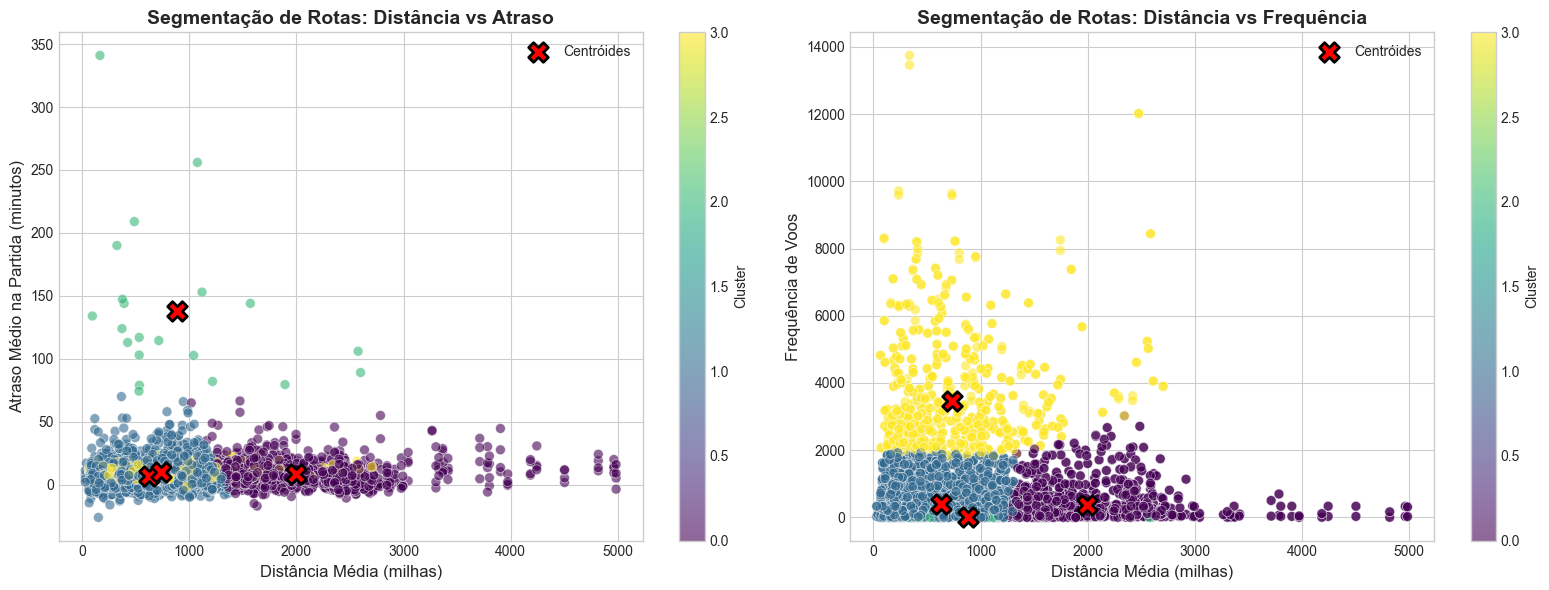

→ Gráfico salvo como 'route_clusters_scatter.png'


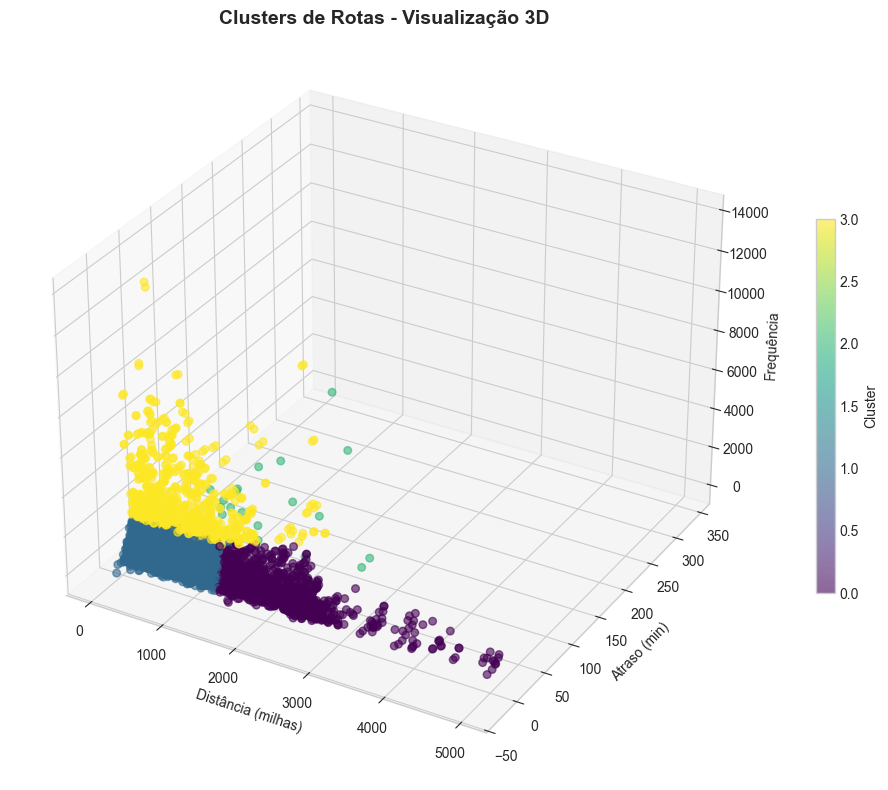

→ Gráfico 3D salvo como 'route_clusters_3d.png'


In [8]:
# =============================================================================
# 6. VISUALIZAÇÃO - SCATTERPLOT
# =============================================================================
# Por que visualizar Distância vs Atraso?
# - São as duas principais dimensões que caracterizam as rotas
# - Permite ver claramente a separação entre clusters

print("\n" + "="*60)
print("VISUALIZAÇÃO DOS CLUSTERS")
print("="*60)

# Gráfico principal: Distância vs Atraso
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Distância vs Atraso
scatter1 = axes[0].scatter(
    route_features_clean['avg_distance'],
    route_features_clean['avg_departure_delay'],
    c=route_features_clean['cluster'],
    cmap='viridis',
    alpha=0.6,
    s=50,
    edgecolors='white',
    linewidth=0.5
)

# Adiciona centróides (des-normalizados)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
axes[0].scatter(
    centroids_original[:, 1],  # avg_distance
    centroids_original[:, 0],  # avg_departure_delay
    c='red',
    marker='X',
    s=200,
    edgecolors='black',
    linewidth=2,
    label='Centróides'
)

axes[0].set_xlabel('Distância Média (milhas)', fontsize=12)
axes[0].set_ylabel('Atraso Médio na Partida (minutos)', fontsize=12)
axes[0].set_title('Segmentação de Rotas: Distância vs Atraso', fontsize=14, fontweight='bold')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Subplot 2: Distância vs Frequência
scatter2 = axes[1].scatter(
    route_features_clean['avg_distance'],
    route_features_clean['flight_count'],
    c=route_features_clean['cluster'],
    cmap='viridis',
    alpha=0.6,
    s=50,
    edgecolors='white',
    linewidth=0.5
)

axes[1].scatter(
    centroids_original[:, 1],  # avg_distance
    centroids_original[:, 2],  # flight_count
    c='red',
    marker='X',
    s=200,
    edgecolors='black',
    linewidth=2,
    label='Centróides'
)

axes[1].set_xlabel('Distância Média (milhas)', fontsize=12)
axes[1].set_ylabel('Frequência de Voos', fontsize=12)
axes[1].set_title('Segmentação de Rotas: Distância vs Frequência', fontsize=14, fontweight='bold')
axes[1].legend()
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('route_clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Gráfico salvo como 'route_clusters_scatter.png'")

# Visualização 3D opcional
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter3d = ax.scatter(
    route_features_clean['avg_distance'],
    route_features_clean['avg_departure_delay'],
    route_features_clean['flight_count'],
    c=route_features_clean['cluster'],
    cmap='viridis',
    alpha=0.6,
    s=30
)

ax.set_xlabel('Distância (milhas)')
ax.set_ylabel('Atraso (min)')
ax.set_zlabel('Frequência')
ax.set_title('Clusters de Rotas - Visualização 3D', fontsize=14, fontweight='bold')
plt.colorbar(scatter3d, label='Cluster', shrink=0.5)

plt.tight_layout()
plt.savefig('route_clusters_3d.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Gráfico 3D salvo como 'route_clusters_3d.png'")

In [9]:
# =============================================================================
# 7. EXEMPLOS DE ROTAS POR CLUSTER
# =============================================================================
print("\n" + "="*60)
print("EXEMPLOS DE ROTAS POR CLUSTER")
print("="*60)

for cluster_id in range(N_CLUSTERS):
    print(f"\n{'─'*40}")
    print(f"CLUSTER {cluster_id} - Top 5 rotas mais frequentes:")
    print(f"{'─'*40}")

    cluster_routes = route_features_clean[route_features_clean['cluster'] == cluster_id]
    top_routes = cluster_routes.nlargest(5, 'flight_count')[
        ['route', 'avg_departure_delay', 'avg_distance', 'flight_count']
    ]

    for _, row in top_routes.iterrows():
        print(f"  {row['route']:20s} | Atraso: {row['avg_departure_delay']:5.1f} min | "
              f"Dist: {row['avg_distance']:6.0f} mi | Voos: {row['flight_count']:,}")


EXEMPLOS DE ROTAS POR CLUSTER

────────────────────────────────────────
CLUSTER 0 - Top 5 rotas mais frequentes:
────────────────────────────────────────
  LAX → MIA            | Atraso:   6.7 min | Dist:   2342 mi | Voos: 3,023
  OGG → LAX            | Atraso:  10.4 min | Dist:   2486 mi | Voos: 2,711
  LAX → OGG            | Atraso:  10.3 min | Dist:   2486 mi | Voos: 2,708
  ATL → SEA            | Atraso:   8.6 min | Dist:   2182 mi | Voos: 2,673
  SEA → ATL            | Atraso:   7.4 min | Dist:   2182 mi | Voos: 2,672

────────────────────────────────────────
CLUSTER 1 - Top 5 rotas mais frequentes:
────────────────────────────────────────
  ATL → LIT            | Atraso:   6.5 min | Dist:    453 mi | Voos: 1,976
  LIT → ATL            | Atraso:   5.2 min | Dist:    453 mi | Voos: 1,976
  MFE → IAH            | Atraso:   5.4 min | Dist:    316 mi | Voos: 1,957
  JAN → IAH            | Atraso:   4.5 min | Dist:    351 mi | Voos: 1,953
  LGB → SLC            | Atraso:   3.3 min | D

In [10]:
# =============================================================================
# 8. EXPORTAÇÃO DOS RESULTADOS
# =============================================================================
print("\n" + "="*60)
print("EXPORTAÇÃO DOS RESULTADOS")
print("="*60)

# Salva o dataframe com clusters
output_file = 'route_clusters_result.csv'
route_features_clean.to_csv(output_file, index=False)
print(f"→ Resultados salvos em '{output_file}'")

# Resumo final
print("\n" + "="*60)
print("RESUMO DA SEGMENTAÇÃO")
print("="*60)
print(f"• Total de rotas analisadas: {len(route_features_clean):,}")
print(f"• Número de clusters: {N_CLUSTERS}")
print(f"• Inércia final: {kmeans_final.inertia_:,.2f}")
print(f"• Features utilizadas: {features_for_clustering}")


EXPORTAÇÃO DOS RESULTADOS
→ Resultados salvos em 'route_clusters_result.csv'

RESUMO DA SEGMENTAÇÃO
• Total de rotas analisadas: 8,570
• Número de clusters: 4
• Inércia final: 11,068.99
• Features utilizadas: ['avg_departure_delay', 'avg_distance', 'flight_count']
